# Analysis and Forecasting of Electricity Prices (Germany, 2018–2025)
## II. EDA

**Importing the required libraries**

In [2]:
import pandas as pd
import numpy as np, random, os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.signal import periodogram
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.stattools import ccf
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import skew, kurtosis, shapiro
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
import holidays
from tabulate import tabulate

**Setting the visualization style**

In [3]:
def set_style():
    mpl.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Georgia'],
        'font.size': 12,

        'axes.titlesize': 12,
        'axes.labelsize': 12,
        'axes.labelcolor': '#444444',

        'axes.grid': True,
        'grid.linestyle': '--',
        'grid.linewidth': 0.6,
        'grid.color': 'lightgray',
        'grid.alpha': 0.35,

        'figure.figsize': (10, 5),
        'lines.linewidth': 1.8,

        'legend.frameon': True,
        'legend.fontsize': 11,
        'legend.labelcolor': '#444444',

        'axes.edgecolor': '#444444',
        'axes.linewidth': 0.7,
        'xtick.color': '#444444',
        'ytick.color': '#444444',

        'axes.prop_cycle': mpl.cycler(color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']),
    })

set_style()

### 1. Data

In [5]:
# Data from multiple sources (SMARD.de, Open-Meteo, Bundesnetzagentur), preprocessed and consolidated into a single dataset in the file Data.ipynb
# Period: October 1, 2018 – October 19, 2025
# Frequency: Weekly
df = pd.read_csv('Day-ahead Prices_2015_2025_Week.csv')

df['week_start'] = pd.to_datetime(df['week_start'], errors='coerce')
df = df.set_index('week_start').sort_index()

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 368 entries, 2018-10-01 to 2025-10-13
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   elec_price         368 non-null    float64
 1   nat_gas_price      368 non-null    float64
 2   wind_speed         368 non-null    float64
 3   sunshine_duration  368 non-null    float64
dtypes: float64(4)
memory usage: 14.4 KB


In [6]:
df.head()

,elec_price,nat_gas_price,wind_speed,sunshine_duration
week_start,,,,
2018-10-01,51.45,26.630,4.377025,51.380006
2018-10-08,54.53,26.860,3.620766,64.365325
2018-10-15,64.00,24.280,2.532683,58.445332
2018-10-22,47.71,24.285,5.586504,22.132139
2018-10-29,46.43,24.325,4.475013,29.297729


### 2. EDA, Model Identification

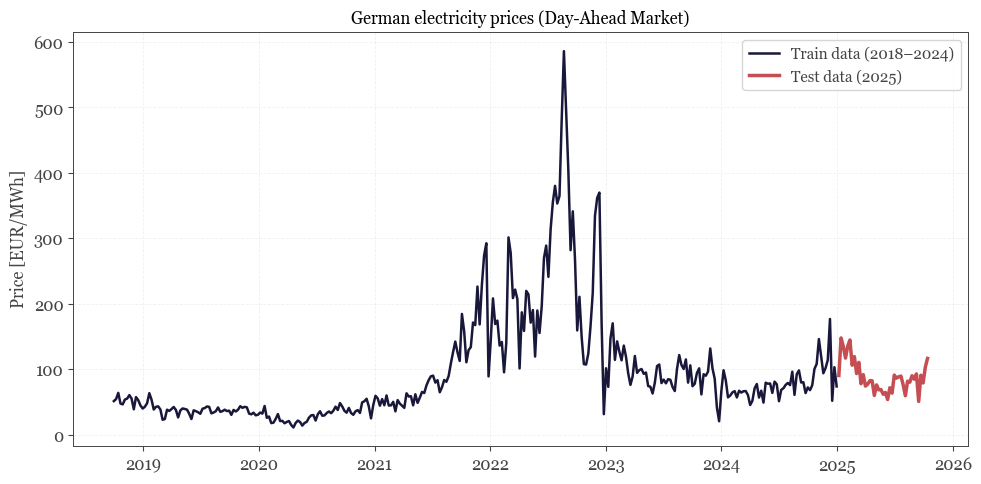

In [15]:
# Germany electricity prices (Day-Ahead Market)
data_odh_start = pd.Timestamp('2018-10-01')
data_odh_end =  pd.Timestamp('2024-12-31')
forecast_start = pd.Timestamp('2025-01-01')
forecast_end = pd.Timestamp('2025-10-20')

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(df.loc[data_odh_start:data_odh_end].index, 
        df.loc[data_odh_start:data_odh_end]['elec_price'],
        color='#19183a',
        label='Train data (2018–2024)')
ax.plot(
    df.loc[forecast_start:forecast_end].index,
    df.loc[forecast_start:forecast_end]['elec_price'],
    color='#C44E52',
    linewidth=2.5,
    label='Test data (2025)'
)

ax.set_title('German electricity prices (Day-Ahead Market)')
ax.set_ylabel('Price [EUR/MWh]')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

In [16]:
# Basic characteristics of electricity prices by period

df_1, df_2, df_3 = (
    df.loc['2018-10-01':'2021-09-27'],
    df.loc['2021-10-04':'2023-03-27'],
    df.loc['2023-04-03':]
)

periods = {
    'Q4 2018 – Q3 2021': df_1,
    'Q4 2021 – Q1 2023': df_2,
    'Q2 2023 – 2025': df_3,  # 2025-10-13
    'Full period': df
}

def compute_stats(series):
    log_returns = np.log(series).diff().dropna()
    return pd.Series({
        'Number of observations': series.count(),
        'Mean': series.mean(),
        'Standard deviation': series.std(),
        'Variance': series.var(),
        'Minimum': series.min(),
        'Maximum': series.max(),
        'Skewness': series.skew(),
        'Kurtosis': series.kurt(),
        'Volatility': log_returns.std()
    })

stats = pd.DataFrame({
    name: compute_stats(df_['elec_price']) 
    for name, df_ in periods.items()
}).round(2)

print(tabulate(stats, headers='keys', tablefmt='github', floatfmt=".2f"))

|                        |   Q4 2018 – Q3 2021 |   Q4 2021 – Q1 2023 |   Q2 2023 – 2025 |   Full period |
|------------------------|---------------------|---------------------|------------------|---------------|
| Number of observations |              157.00 |               78.00 |           133.00 |        368.00 |
| Mean                   |               44.47 |              206.42 |            84.62 |         93.31 |
| Standard deviation     |               21.50 |              106.08 |            23.56 |         80.77 |
| Variance               |              462.07 |            11252.39 |           554.87 |       6523.85 |
| Minimum                |               11.19 |               31.50 |            20.69 |         11.19 |
| Maximum                |              142.36 |              585.92 |           176.85 |        585.92 |
| Skewness               |                1.88 |                1.24 |             0.81 |          2.55 |
| Kurtosis               |                4.91

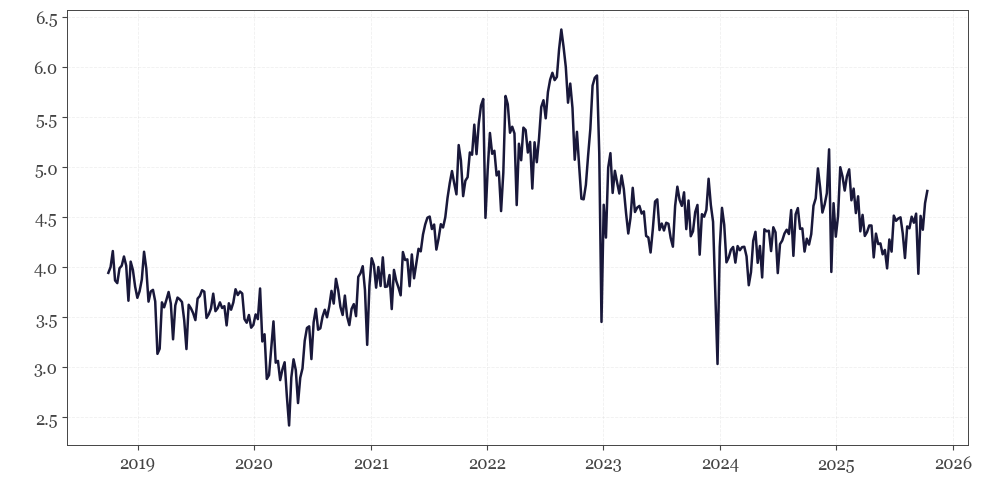

In [18]:
#Log-transformed electricity price time series
df['ln_el_price'] = np.log(df['elec_price'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df['ln_el_price'], color='#19183a')
ax.set_ylabel(' ')
plt.tight_layout()
plt.show()

#### 2.1 Stationarity Tests: ADF, KPSS

In [21]:
# Testing the stationarity of the log-transformed electricity price time series
adf_test = adfuller(df['ln_el_price'], regression='ct', autolag='AIC')
kpss_test = kpss(df['ln_el_price'], regression='ct')

results_table = pd.DataFrame({
    'Test': ['ADF', 'KPSS'],
    'Test statistic': [adf_test[0], kpss_test[0]],
    'p-value': [adf_test[1], kpss_test[1]],
    'Critical value (α = 0.05)': [adf_test[4]['5%'], kpss_test[3]['5%']]
}).round(3)

print(results_table.to_markdown(index=False))

| Test   |   Test statistic |   p-value |   Critical value (α = 0.05) |
|:-------|-----------------:|----------:|----------------------------:|
| ADF    |           -1.829 |     0.691 |                      -3.423 |
| KPSS   |            0.435 |     0.01  |                       0.146 |


/tmp/ipykernel_459423/3354323291.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(df['ln_el_price'], regression='ct')


#### 2.2 ACF and PACF of the log-transformed time series

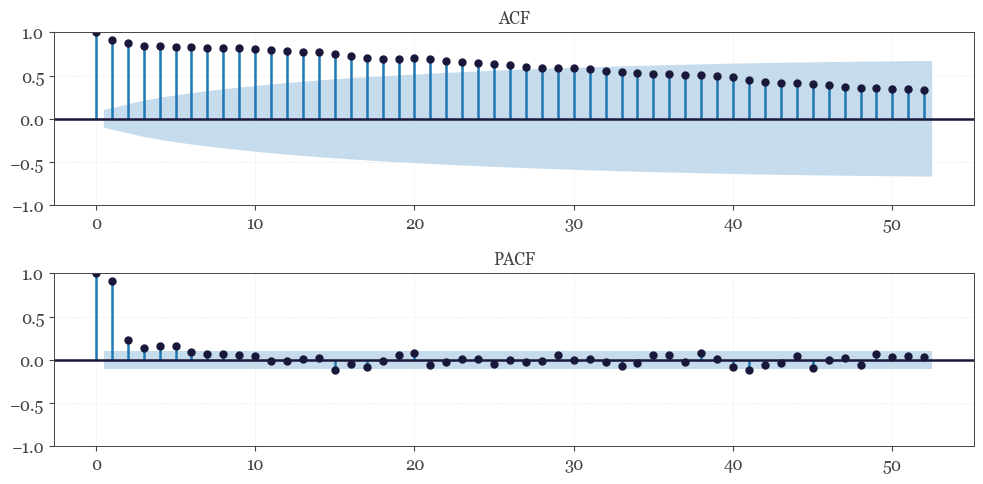

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

plot_acf(df['ln_el_price'], ax=axes[0], lags=52, color='#19183a')
axes[0].set_title('ACF', color='#444444')

plot_pacf(df['ln_el_price'].dropna(), ax=axes[1], lags=52, method='ywm', color='#19183a')
axes[1].set_title('PACF', color='#444444')

plt.tight_layout()
plt.show()

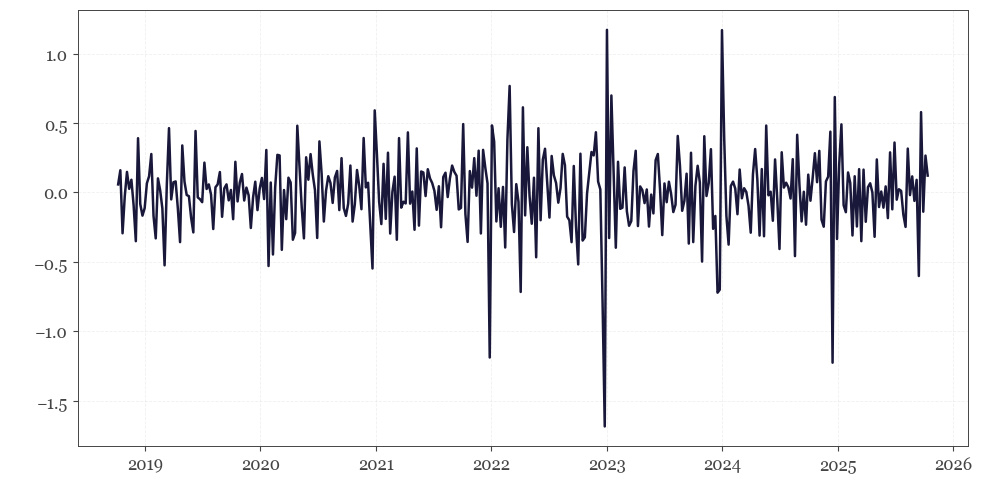

In [24]:
# First difference of the log-transformed electricity price
df['d_ln_el_price'] = df['ln_el_price'].diff()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df['d_ln_el_price'], color='#19183a')
ax.set_ylabel(' ')
plt.tight_layout()
plt.show()

In [25]:
# Results of ADF and KPSS tests for the log-transformed electricity prices after first differencing
adf_test_2 = adfuller(df['d_ln_el_price'].dropna(), regression='c', autolag='AIC')
kpss_test_2 = kpss(df['d_ln_el_price'].dropna(), regression='c')

results_table_2 = pd.DataFrame({
    'Test': ['ADF', 'KPSS'],
    'Test statistic': [adf_test_2[0], kpss_test_2[0]],
    'p-value': [adf_test_2[1], kpss_test_2[1]],
    'Critical value (α = 0.05)': [adf_test_2[4]['5%'], kpss_test_2[3]['5%']]
}).round(3)

print(results_table_2.to_markdown(index=False))

| Test   |   Test statistic |   p-value |   Critical value (α = 0.05) |
|:-------|-----------------:|----------:|----------------------------:|
| ADF    |          -11.279 |       0   |                      -2.87  |
| KPSS   |            0.086 |       0.1 |                       0.463 |


/tmp/ipykernel_459423/1106499524.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test_2 = kpss(df['d_ln_el_price'].dropna(), regression='c')


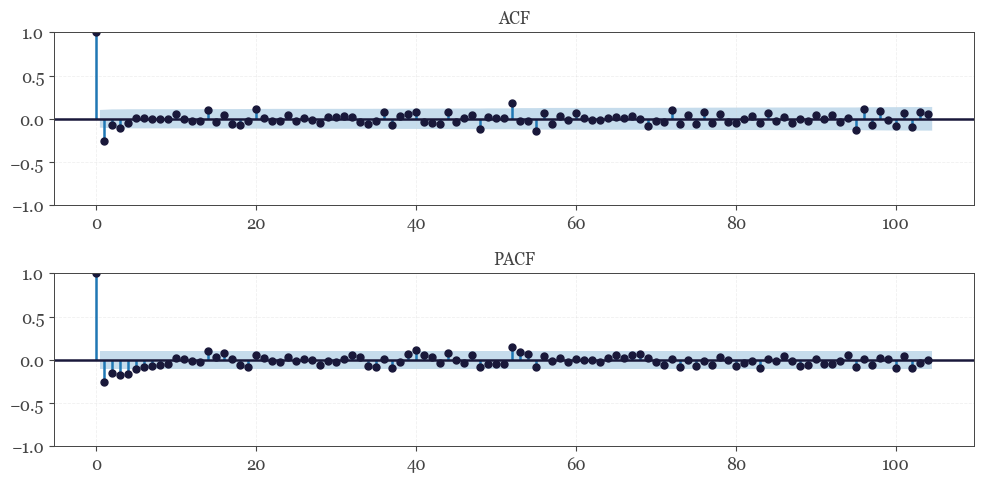

In [26]:
# ACF and PACF of the log-transformed electricity price time series after first differencing
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

plot_acf(df['d_ln_el_price'].dropna(), ax=axes[0], lags=104, color='#19183a')
axes[0].set_title('ACF', color='#444444')

plot_pacf(df['d_ln_el_price'].dropna(), ax=axes[1], lags=104, method='ywm', color='#19183a')
axes[1].set_title('PACF', color='#444444')

plt.tight_layout()
plt.show()